# Initialisation: choose a useful start

**Google Colab:** use a CPU runtime. Run the cells from top to bottom.

### Before the first gradient step

A network cannot start empty. Every weight needs a number in it before training begins.

Gradient descent tells us how to **move** the weights. It never tells us where to **stand**.

**So the question for this session: does the starting point matter?**

The data, the network and the learning rate stay fixed. Only the starting weights change. We watch real training each time.

| # | Starting weights |
|---|---|
| 1 | Zero, one neuron |
| 2 | Zero, deep network |
| 3 | The same value everywhere |
| 4 | Random and tiny (0.01) |
| 5 | Random and large (3) |
| 6 | Xavier, with tanh |
| 7 | Xavier, with ReLU |
| 8 | He, with ReLU |

Each one fails in a way that tells us what the next one has to fix.

## Data

Two curved classes. **400 training points. 200 validation points.** Validation points never update the weights.

The classes curve around each other, so no straight line separates them. That is why we need hidden layers.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras, GradientTape
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from IPython.display import clear_output, display, HTML
from html import escape

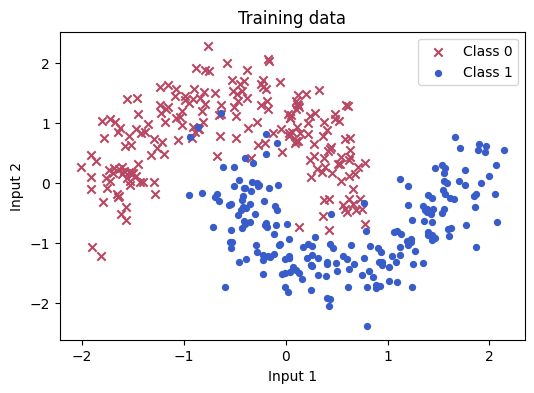

In [ ]:
X, y = make_moons(n_samples=600, noise=0.18, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=1/3, stratify=y, random_state=42
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype("float32")
X_val = scaler.transform(X_val).astype("float32")

plt.figure(figsize=(6, 4))
plt.scatter(*X_train[y_train == 0].T, marker="x", color="#B74763", label="Class 0")
plt.scatter(*X_train[y_train == 1].T, color="#385DCA", label="Class 1", s=18)
plt.xlabel("Input 1")
plt.ylabel("Input 2")
plt.title("Training data")
plt.legend()
plt.show()

point_ids = [np.flatnonzero(y_train == 0)[0], np.flatnonzero(y_train == 1)[0]]

### Keep the experiment fixed

Start with one sigmoid neuron. Then use **eight hidden layers of 16 neurons**.

Every run uses 150 epochs, one full-batch update per epoch and learning rate **0.1**. Biases start at zero. Each tanh/ReLU pair starts with the same weights.

**Only one thing changes between runs: the starting weights.** So when a run fails, the starting weights are the reason.

### Read the output

**Loss falls. Accuracy rises.** Graphs update every epoch. Solid lines show training; dashed lines show validation.

Each run has **one small evidence table**. Numbers are rounded decimals. `tiny +` and `tiny −` mean non-zero values with magnitude below **0.000001**.

Very large losses use a labelled log scale. A non-finite value means the calculation failed.

### Display helpers

These cells draw the graphs and tables. Each experiment below writes its own complete network.

Gradients use the displayed weights, before the next update. Gradient size summarises a layer using the square root of its mean squared gradients.

In [ ]:
# @title
def decimal(value):
    if isinstance(value, str):
        return value
    if not np.isfinite(value):
        return "Non-finite"
    if value == 0:
        return "0"
    if abs(value) < 0.000001:
        return "tiny +" if value > 0 else "tiny −"
    places = 2 if abs(value) >= 1000 else 6
    return f"{value:,.{places}f}".rstrip("0").rstrip(".")


def show_table(headers, rows):
    cells = [[decimal(value) for value in row] for row in rows]
    head = "".join(f"<th>{escape(label)}</th>" for label in headers)
    body = "".join("<tr>" + "".join(f"<td>{escape(v)}</td>" for v in row) + "</tr>" for row in cells)
    note = "tiny + / tiny −: non-zero, with magnitude below 0.000001." if any("tiny" in v for row in cells for v in row) else ""
    display(HTML(f"""<style>
    .evidence {{border-collapse:collapse; font:16px system-ui; margin:12px 0;}}
    .evidence th,.evidence td {{padding:10px 16px; border-bottom:1px solid #DCE2EB; text-align:right;}}
    .evidence th {{background:#E9EFFA; color:#244575;}}
    .evidence tr:nth-child(even) {{background:#F6F8FC;}}
    </style><table class="evidence"><thead><tr>{head}</tr></thead><tbody>{body}</tbody></table>
    <p style="font:14px system-ui;color:#4B5563">{note}</p>"""))


def measure(model, probe, epoch, kind):
    loss_fn = keras.losses.BinaryCrossentropy()
    with GradientTape() as tape:
        loss = loss_fn(y_train[:, None], model(X_train, training=False))
    gradients = tape.gradient(loss, model.trainable_weights)
    W, G = model.layers[0].kernel.numpy(), gradients[0].numpy()
    row = {"epoch": epoch, "weight": float(W[0, 0]), "gradient": float(G[0, 0])}
    if kind == "equal":
        row.update(weight_b=float(W[0, 1]), gradient_b=float(G[0, 1]))
    if kind == "zero":
        row["points"] = []
        for i in point_ids:
            with GradientTape() as tape:
                loss = loss_fn(y_train[i:i+1, None], model(X_train[i:i+1], training=False))
            g = tape.gradient(loss, model.trainable_weights)
            row["points"].append([int(y_train[i]), max(float(np.abs(v.numpy()).max()) for v in g[::2]), float(g[-1][0])])
    if kind in ["small", "large_tanh"]:
        row["sizes"] = [float(np.sqrt(np.mean(g.numpy().astype("float64")**2))) for g in gradients[::2]]
    if kind == "large_tanh":
        row["flat"] = [float(100 * np.mean(np.abs(a.numpy()) > 0.99)) for a in probe(X_train)]
    return row


def show_evidence(live):
    rows, kind = live.snapshots, live.kind
    first, last = rows[0], rows[-1]
    if kind in ["single", "large_relu"]:
        selected = rows[:2] + ([last] if len(rows) > 2 else [])
        show_table(["Epoch", "Input 1 weight", "Its gradient"],
                   [[r["epoch"], r["weight"], r["gradient"]] for r in selected])
    elif kind == "zero":
        selected = [first, last] if last is not first else [first]
        show_table(["Epoch", "Target", "Largest |weight gradient|", "Output bias gradient"],
                   [[r["epoch"], *point] for r in selected for point in r["points"]])
    elif kind == "equal":
        show_table(["Epoch", "Weight A", "Weight B", "Gradient A", "Gradients equal?"],
                   [[r["epoch"], r["weight"], r["weight_b"], r["gradient"], "Yes" if r["gradient"] == r["gradient_b"] else "No"] for r in rows])
    elif kind == "small":
        show_table(["Hidden layer", "Initial gradient size"],
                   [[i+1, first["sizes"][i]] for i in [0, 3, 7]])
    elif kind == "large_tanh":
        show_table(["Hidden layer", "Initially near ±1 (%)", "Initial gradient size"],
                   [[i+1, round(first["flat"][i], 1), first["sizes"][i]] for i in [0, 3, 7]])
    else:
        show_table(["Epoch", "Training loss", "Validation loss"],
                   [[i, live.values["loss"][i-1], live.values["val_loss"][i-1]]
                    for i in [1, 10, 150] if i <= len(live.values["loss"])])


def compare_runs(tanh_history, relu_history, title):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for history, label, colour in [(tanh_history, "tanh", "#385DCA"),
                                   (relu_history, "ReLU", "#B74763")]:
        for ax, metric in zip(axes, ["loss", "accuracy"]):
            for prefix, split, style in [("", "train", "-"), ("val_", "validation", "--")]:
                values = history.history[prefix + metric]
                ax.plot(np.arange(1, len(values) + 1), values, style,
                        color=colour, label=label + " " + split,
                        marker="." if not np.isfinite(values).all() else None)
        if not all(np.isfinite(values).all() for values in history.history.values()):
            axes[0].text(0.04, 0.85, f"{label} stopped at epoch {len(values)}: non-finite loss",
                         transform=axes[0].transAxes, color=colour, fontsize=10)
    axes[0].set_yscale("symlog", linthresh=1)
    axes[0].set(ylabel="Loss (linear below 1, log above)", ylim=(0, None))
    axes[1].set(ylabel="Accuracy", ylim=(0, 1))
    for ax in axes:
        ax.set(xlabel="Epoch")
        ax.legend(fontsize=10)
        ax.grid(alpha=0.2)
    fig.suptitle(title + ": tanh and ReLU")
    plt.tight_layout()
    plt.show()


In [ ]:
# @title
class LivePlot(keras.callbacks.Callback):
    def __init__(self, title, kind):
        super().__init__()
        self.title = title
        self.kind = kind

    def on_train_begin(self, logs=None):
        self.values = {key: [] for key in ["loss", "val_loss", "accuracy", "val_accuracy"]}
        self.probe = keras.Model(self.model.inputs[0], [layer.output for layer in self.model.layers[:-1]]) if self.kind == "large_tanh" else None
        self.snapshots = [measure(self.model, self.probe, 0, self.kind)]

    def on_epoch_end(self, epoch, logs=None):
        for key in self.values:
            self.values[key].append(logs[key])
        if epoch + 1 in [1, 10, self.params["epochs"]] or self.model.stop_training:
            self.snapshots.append(measure(self.model, self.probe, epoch + 1, self.kind))
        epochs = np.arange(1, epoch + 2)
        fig, axes = plt.subplots(1, 2, figsize=(11, 4))
        for ax, metric in zip(axes, ["loss", "accuracy"]):
            ax.plot(epochs, self.values[metric], color="#385DCA", marker=".",
                    markersize=3, label="Training")
            ax.plot(epochs, self.values["val_" + metric], color="#B74763",
                    linestyle="--", marker=".", markersize=3, label="Validation")
            ax.set(xlabel="Epoch", ylabel=metric.capitalize(),
                   xlim=(1, max(2, self.params["epochs"])))
            ax.legend()
            ax.grid(alpha=0.2)
        axes[0].set_ylim(0, max(0.8, axes[0].get_ylim()[1]))
        if axes[0].get_ylim()[1] > 10:
            axes[0].set_yscale("symlog", linthresh=1)
            axes[0].set_ylabel("Loss (log above 1)")
        axes[1].set_ylim(0, 1)
        fig.suptitle(f"{self.title} · Epoch {epoch + 1}/{self.params['epochs']}")
        plt.tight_layout()
        clear_output(wait=True)
        display(fig)
        plt.close(fig)
        show_evidence(self)
        if self.model.stop_training:
            print("Training stopped: the loss became non-finite.")


## 1. We need a number to start with. Let us choose zero

Zero is the simplest choice available, and it looks harmless.

Test it on the smallest network first: **one sigmoid neuron**, no hidden layers, built with `Sequential` and `Dense(1)`.

**Can a weight of zero move at all?**

With binary cross-entropy:

$$g_w=(\hat y-y)x,\qquad w_{\mathrm{new}}=w-0.1g_w$$

If $x=1$ and $y=1$, then $g_w=(0.5-1)\times1=-0.5$. The new weight is **0.05**.

The weight is zero. The gradient is not.

**Watch:** the weight column in the table, from epoch 0 onwards.

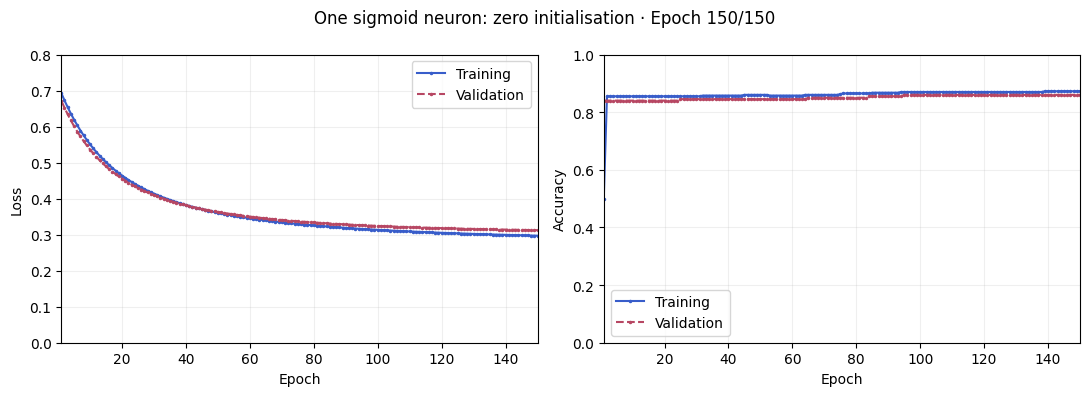

Epoch,Input 1 weight,Its gradient
0,0,-0.275719
1,0.027572,-0.265494
150,0.982101,-0.013426


In [ ]:
keras.utils.set_random_seed(42)

perceptron_model = keras.Sequential([
    keras.Input(shape=(2,)),
    keras.layers.Dense(1, activation="sigmoid",
                       kernel_initializer=keras.initializers.Zeros(), bias_initializer="zeros")
])
perceptron_model.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.1),
    loss="binary_crossentropy", metrics=["accuracy"]
)
perceptron_live = LivePlot("One sigmoid neuron: zero initialisation", "single")
perceptron_history = perceptron_model.fit(
    X_train, y_train, validation_data=(X_val, y_val),
    epochs=150, batch_size=len(X_train), shuffle=False, verbose=0,
    callbacks=[perceptron_live]
)

**Result:** the weight starts at 0 with gradient **−0.2757**, and reaches **0.982** by epoch 150. The loss falls. **Zero was fine here.**

Why: the gradient is $(\hat y-y)\times x$, and the input $x$ is not zero. Nothing in that product is zero, so the weight moves.

But one neuron only draws a straight line, and our data is curved.

**Next:** put the same zero start into a deep network.

### One more choice: tanh or ReLU?

From here on, every experiment runs **twice**: once with tanh hidden layers, once with ReLU. The activation decides what the gradient gets multiplied by on the way back, so it is part of the story.

| | tanh | ReLU |
|---|---|---|
| Output | Between −1 and 1 | $\max(0,z)$ |
| Slope | $1-h^2$ | 1 for positive inputs; 0 for negative inputs |
| At zero | Slope 1 | Keras uses slope 0 |

Both output **zero** at zero. Compare their shapes below.

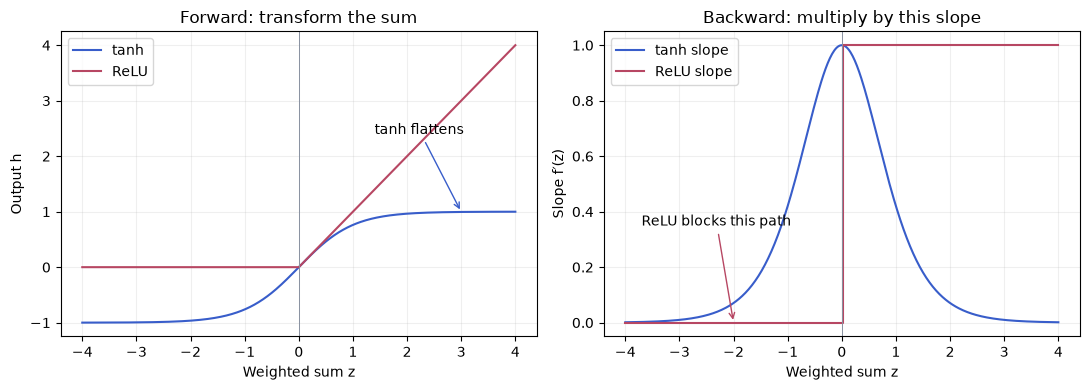

In [ ]:
z = np.linspace(-4, 4, 401)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(z, np.tanh(z), color="#385DCA", label="tanh")
axes[0].plot(z, np.maximum(0, z), color="#B74763", label="ReLU")
axes[1].plot(z, 1 - np.tanh(z)**2, color="#385DCA", label="tanh slope")
axes[1].step(z, (z > 0).astype(float), where="post", color="#B74763", label="ReLU slope")
axes[0].set(ylabel="Output h", title="Forward: transform the sum")
axes[1].set(ylabel="Slope f′(z)", title="Backward: multiply by this slope")
axes[0].annotate("tanh flattens", xy=(3, np.tanh(3)), xytext=(1.4, 2.4),
                 arrowprops={"arrowstyle": "->", "color": "#385DCA"})
axes[1].annotate("ReLU blocks this path", xy=(-2, 0), xytext=(-3.7, 0.35),
                 arrowprops={"arrowstyle": "->", "color": "#B74763"})
for ax in axes:
    ax.set(xlabel="Weighted sum z")
    ax.axvline(0, color="#8891A0", linewidth=0.7)
    ax.legend()
    ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 2. The same zero start, now in an MLP with tanh

Eight hidden layers, 16 neurons each, every weight zero.

For one hidden neuron, let $w$ enter it and $v$ leave it. At the zero start, $h=0$ and $v=0$:

$$g_v=(\hat y-y)\underbrace{h}_{0}=0$$
$$g_w=(\hat y-y)\underbrace{v}_{0}f'(0)x=0$$

**Zero weight gradients give zero weight updates.** The same zero factors occur at every layer.

The table checks one example from each class. Their **bias** gradients need not be zero.

**Watch:** the accuracy line, and the weight gradient column.

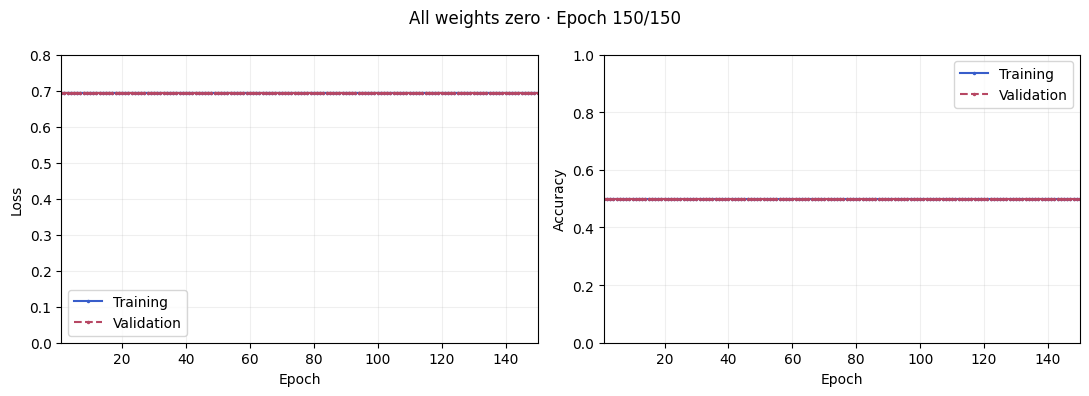

Epoch,Target,Largest |weight gradient|,Output bias gradient
0,0,0,0.5
0,1,0,-0.5
150,0,0,0.5
150,1,0,-0.5


In [ ]:
keras.utils.set_random_seed(42)

zero_model = keras.Sequential([
    keras.Input(shape=(2,)),
    keras.layers.Dense(16, activation="tanh", kernel_initializer=keras.initializers.Zeros()),
    keras.layers.Dense(16, activation="tanh", kernel_initializer=keras.initializers.Zeros()),
    keras.layers.Dense(16, activation="tanh", kernel_initializer=keras.initializers.Zeros()),
    keras.layers.Dense(16, activation="tanh", kernel_initializer=keras.initializers.Zeros()),
    keras.layers.Dense(16, activation="tanh", kernel_initializer=keras.initializers.Zeros()),
    keras.layers.Dense(16, activation="tanh", kernel_initializer=keras.initializers.Zeros()),
    keras.layers.Dense(16, activation="tanh", kernel_initializer=keras.initializers.Zeros()),
    keras.layers.Dense(16, activation="tanh", kernel_initializer=keras.initializers.Zeros()),
    keras.layers.Dense(1, activation="sigmoid", kernel_initializer=keras.initializers.Zeros())
])

zero_model.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.1),
    loss="binary_crossentropy", metrics=["accuracy"]
)
zero_live = LivePlot("All weights zero", "zero")
zero_history = zero_model.fit(
    X_train, y_train, validation_data=(X_val, y_val),
    epochs=150, batch_size=len(X_train), shuffle=False, verbose=0,
    callbacks=[zero_live]
)

### Try replacing tanh with ReLU

Only the activation changes. Same zero weights, same everything else.

Does a different activation rescue this start?

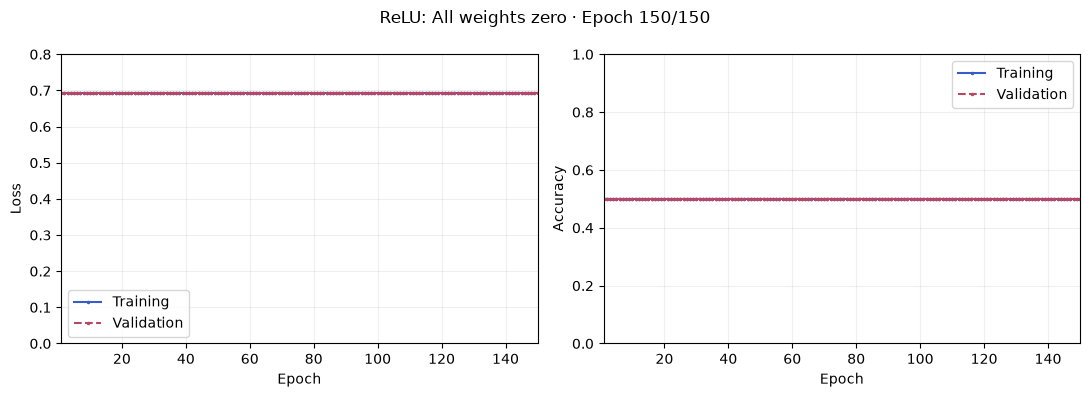

Epoch,Target,Largest |weight gradient|,Output bias gradient
0,0,0,0.5
0,1,0,-0.5
150,0,0,0.5
150,1,0,-0.5


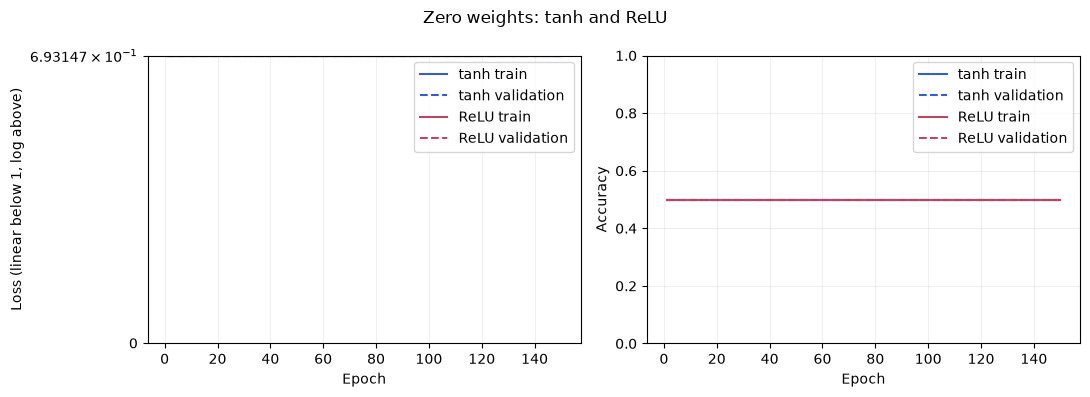

In [ ]:
keras.utils.set_random_seed(42)

zero_relu_model = keras.Sequential([
    keras.Input(shape=(2,)),
    keras.layers.Dense(16, activation="relu", kernel_initializer=keras.initializers.Zeros()),
    keras.layers.Dense(16, activation="relu", kernel_initializer=keras.initializers.Zeros()),
    keras.layers.Dense(16, activation="relu", kernel_initializer=keras.initializers.Zeros()),
    keras.layers.Dense(16, activation="relu", kernel_initializer=keras.initializers.Zeros()),
    keras.layers.Dense(16, activation="relu", kernel_initializer=keras.initializers.Zeros()),
    keras.layers.Dense(16, activation="relu", kernel_initializer=keras.initializers.Zeros()),
    keras.layers.Dense(16, activation="relu", kernel_initializer=keras.initializers.Zeros()),
    keras.layers.Dense(16, activation="relu", kernel_initializer=keras.initializers.Zeros()),
    keras.layers.Dense(1, activation="sigmoid", kernel_initializer=keras.initializers.Zeros())
])

zero_relu_model.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.1),
    loss="binary_crossentropy", metrics=["accuracy"]
)
zero_relu_live = LivePlot("ReLU: All weights zero", "zero")
zero_relu_history = zero_relu_model.fit(
    X_train, y_train, validation_data=(X_val, y_val),
    epochs=150, batch_size=len(X_train), shuffle=False, verbose=0,
    callbacks=[zero_relu_live]
)

compare_runs(zero_history, zero_relu_history, "Zero weights")

**Result:** both networks sit at 50% accuracy for 150 epochs. Every weight gradient is exactly **0**, at epoch 0 and still at epoch 150.

Why: a hidden weight's gradient carries the outgoing weight $v$ as a factor, and every $v$ is zero. Zero gradient, zero update, so the weights stay at zero forever. ReLU adds a second zero (its slope at 0) and changes nothing.

The output **bias** does get a gradient, $+0.5$ and $-0.5$ for the two classes, but those cancel across this balanced batch.

**The lesson:** zero is not too small, it is **stuck**. The single neuron escaped because its input $x$ was non-zero. A hidden neuron has no such luck: its input is another zero.

**Next:** keep every weight the same, but make it non-zero.

## 3. Non-zero, but all identical: every weight 0.5

Maybe the problem was the value 0 itself. Set every weight to **0.5** instead.

Drawing one random number and copying it everywhere has exactly the same shape, so this covers that idea too.

The table follows input 1's connections to hidden neurons **A and B**. The last column checks their gradients before rounding.

$$w_A=w_B,\quad g_A=g_B\quad\Rightarrow\quad w_A^{\mathrm{new}}=w_B^{\mathrm{new}}$$

Two identical copies still give one feature: $v_1h+v_2h=(v_1+v_2)h$.

**Watch:** the "Gradients equal?" column.

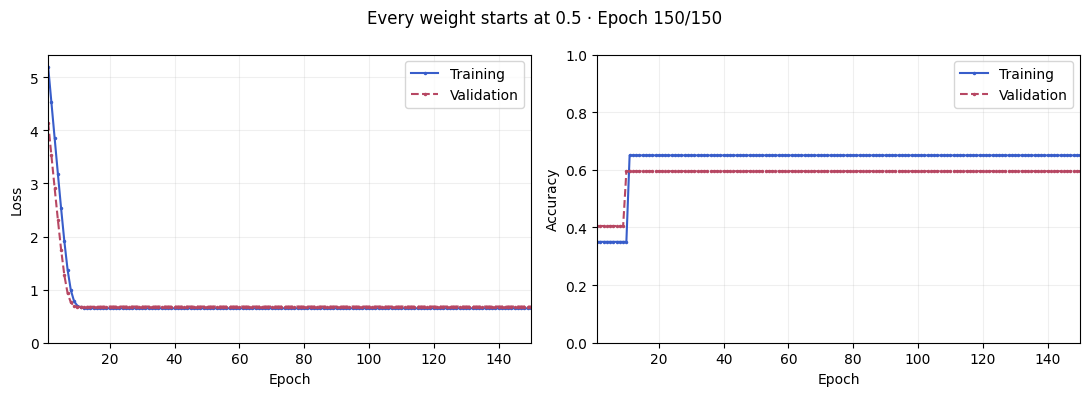

Epoch,Weight A,Weight B,Gradient A,Gradients equal?
0,0.5,0.5,0,Yes
1,0.5,0.5,0,Yes
10,0.5,0.5,0,Yes
150,0.5,0.5,0,Yes


In [ ]:
keras.utils.set_random_seed(42)

equal_model = keras.Sequential([
    keras.Input(shape=(2,)),
    keras.layers.Dense(16, activation="tanh", kernel_initializer=keras.initializers.Constant(0.5)),
    keras.layers.Dense(16, activation="tanh", kernel_initializer=keras.initializers.Constant(0.5)),
    keras.layers.Dense(16, activation="tanh", kernel_initializer=keras.initializers.Constant(0.5)),
    keras.layers.Dense(16, activation="tanh", kernel_initializer=keras.initializers.Constant(0.5)),
    keras.layers.Dense(16, activation="tanh", kernel_initializer=keras.initializers.Constant(0.5)),
    keras.layers.Dense(16, activation="tanh", kernel_initializer=keras.initializers.Constant(0.5)),
    keras.layers.Dense(16, activation="tanh", kernel_initializer=keras.initializers.Constant(0.5)),
    keras.layers.Dense(16, activation="tanh", kernel_initializer=keras.initializers.Constant(0.5)),
    keras.layers.Dense(1, activation="sigmoid", kernel_initializer=keras.initializers.Constant(0.5))
])

equal_model.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.1),
    loss="binary_crossentropy", metrics=["accuracy"]
)
equal_live = LivePlot("Every weight starts at 0.5", "equal")
equal_history = equal_model.fit(
    X_train, y_train, validation_data=(X_val, y_val),
    epochs=150, batch_size=len(X_train), shuffle=False, verbose=0,
    callbacks=[equal_live]
)

### Try replacing tanh with ReLU

Can a different activation break the tie?

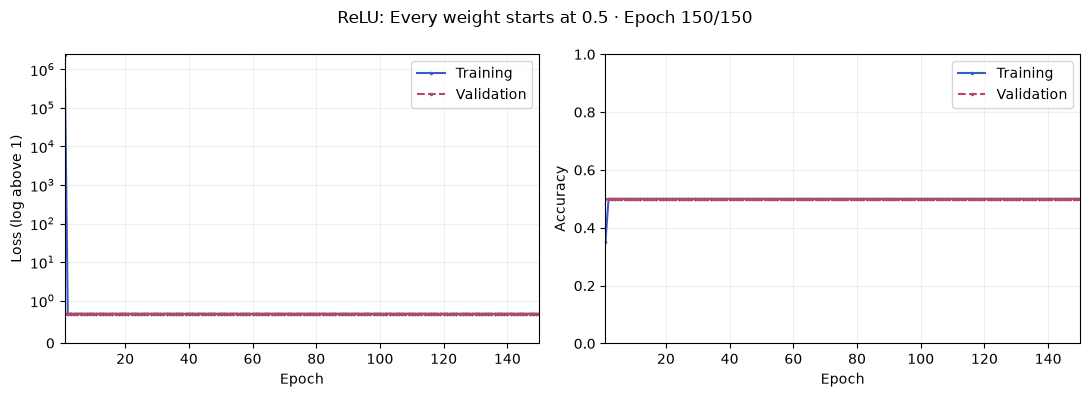

Epoch,Weight A,Weight B,Gradient A,Gradients equal?
0,0.5,0.5,"-32,199.56",Yes
1,"3,220.46","3,220.46",0,Yes
10,"3,220.46","3,220.46",0,Yes
150,"3,220.46","3,220.46",0,Yes


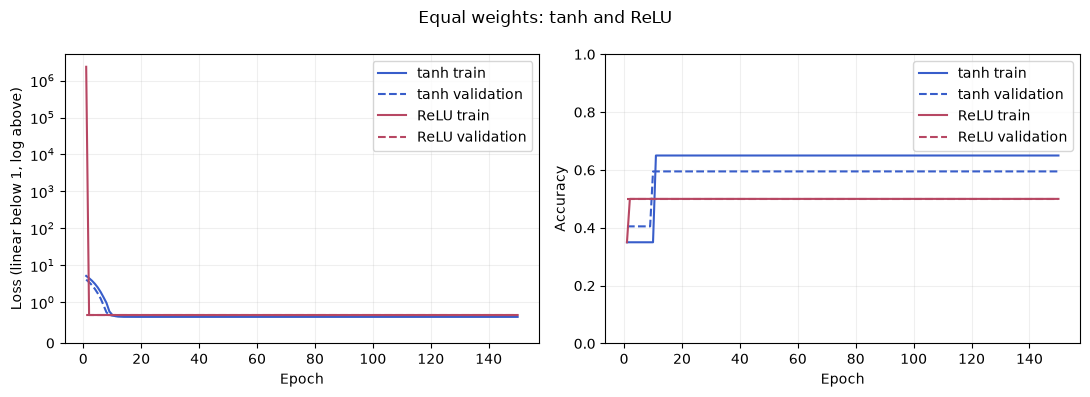

In [ ]:
keras.utils.set_random_seed(42)

equal_relu_model = keras.Sequential([
    keras.Input(shape=(2,)),
    keras.layers.Dense(16, activation="relu", kernel_initializer=keras.initializers.Constant(0.5)),
    keras.layers.Dense(16, activation="relu", kernel_initializer=keras.initializers.Constant(0.5)),
    keras.layers.Dense(16, activation="relu", kernel_initializer=keras.initializers.Constant(0.5)),
    keras.layers.Dense(16, activation="relu", kernel_initializer=keras.initializers.Constant(0.5)),
    keras.layers.Dense(16, activation="relu", kernel_initializer=keras.initializers.Constant(0.5)),
    keras.layers.Dense(16, activation="relu", kernel_initializer=keras.initializers.Constant(0.5)),
    keras.layers.Dense(16, activation="relu", kernel_initializer=keras.initializers.Constant(0.5)),
    keras.layers.Dense(16, activation="relu", kernel_initializer=keras.initializers.Constant(0.5)),
    keras.layers.Dense(1, activation="sigmoid", kernel_initializer=keras.initializers.Constant(0.5))
])

equal_relu_model.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.1),
    loss="binary_crossentropy", metrics=["accuracy"]
)
equal_relu_live = LivePlot("ReLU: Every weight starts at 0.5", "equal")
equal_relu_history = equal_relu_model.fit(
    X_train, y_train, validation_data=(X_val, y_val),
    epochs=150, batch_size=len(X_train), shuffle=False, verbose=0,
    callbacks=[keras.callbacks.TerminateOnNaN(), equal_relu_live]
)

compare_runs(equal_history, equal_relu_history, "Equal weights")

**Result:** "Gradients equal?" says **Yes** at every epoch, with both activations. The neurons never separate.

Why: neurons in a layer see the same inputs and hold the same weights, so they receive the same gradient and take the same step. Sixteen identical neurons do the work of one.

The ReLU run also shows what a bad scale does on its own: weight A jumps from 0.5 to **3,220** in the first update, after which its gradient is 0 and the layer is dead.

**The lesson:** the fix is **randomness**, not a better constant. Neurons have to start different to become different.

**Next:** random weights.

## 4. Random at last, but tiny: standard deviation 0.01

Every weight now gets its own draw from a normal distribution. Keep them small, to be safe.

Backpropagation multiplies by the weights on the way back. Along one path through two layers, $0.01\times0.01=0.0001$. There are eight layers.

**Watch:** the initial gradient sizes in hidden layers 1, 4 and 8.

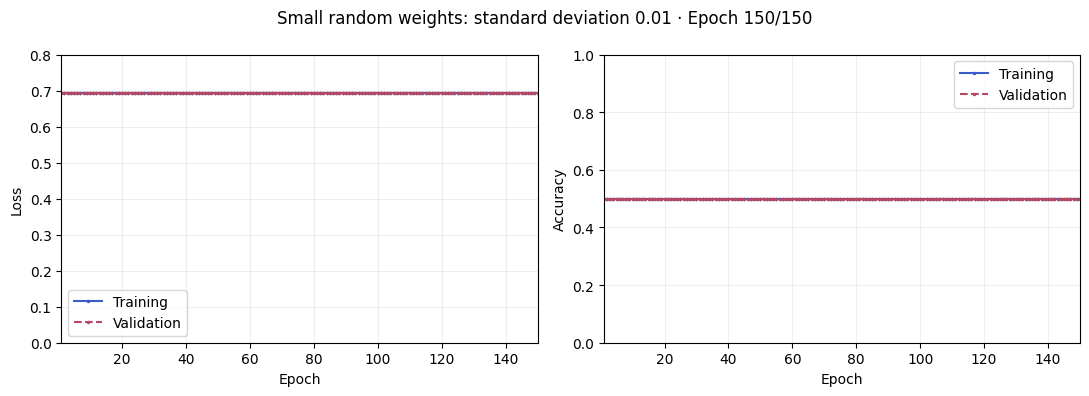

Hidden layer,Initial gradient size
1,tiny +
4,tiny +
8,tiny +


In [ ]:
keras.utils.set_random_seed(42)

small_model = keras.Sequential([
    keras.Input(shape=(2,)),
    keras.layers.Dense(16, activation="tanh", kernel_initializer=keras.initializers.RandomNormal(stddev=0.01)),
    keras.layers.Dense(16, activation="tanh", kernel_initializer=keras.initializers.RandomNormal(stddev=0.01)),
    keras.layers.Dense(16, activation="tanh", kernel_initializer=keras.initializers.RandomNormal(stddev=0.01)),
    keras.layers.Dense(16, activation="tanh", kernel_initializer=keras.initializers.RandomNormal(stddev=0.01)),
    keras.layers.Dense(16, activation="tanh", kernel_initializer=keras.initializers.RandomNormal(stddev=0.01)),
    keras.layers.Dense(16, activation="tanh", kernel_initializer=keras.initializers.RandomNormal(stddev=0.01)),
    keras.layers.Dense(16, activation="tanh", kernel_initializer=keras.initializers.RandomNormal(stddev=0.01)),
    keras.layers.Dense(16, activation="tanh", kernel_initializer=keras.initializers.RandomNormal(stddev=0.01)),
    keras.layers.Dense(1, activation="sigmoid", kernel_initializer=keras.initializers.RandomNormal(stddev=0.01))
])

small_model.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.1),
    loss="binary_crossentropy", metrics=["accuracy"]
)
small_live = LivePlot("Small random weights: standard deviation 0.01", "small")
small_history = small_model.fit(
    X_train, y_train, validation_data=(X_val, y_val),
    epochs=150, batch_size=len(X_train), shuffle=False, verbose=0,
    callbacks=[small_live]
)

### Try replacing tanh with ReLU

ReLU's slope is a clean 1 on the positive side, so it loses nothing there. Does that save it?

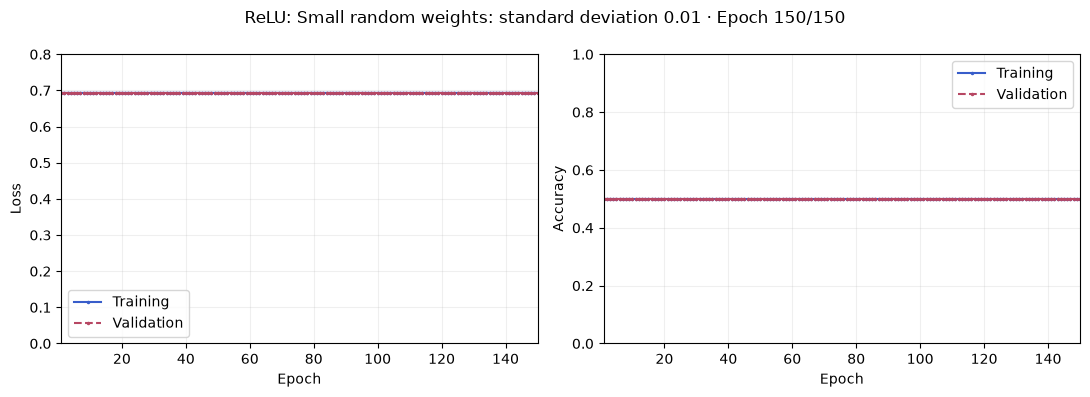

Hidden layer,Initial gradient size
1,tiny +
4,tiny +
8,tiny +


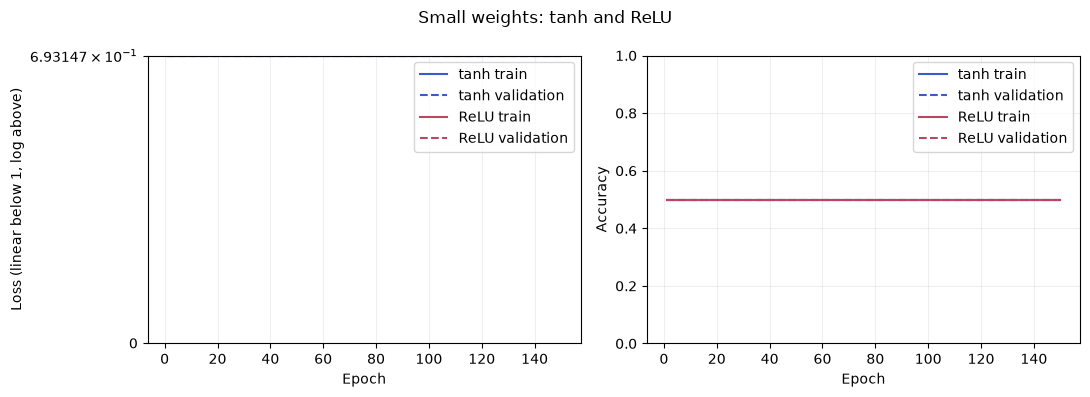

In [ ]:
keras.utils.set_random_seed(42)

small_relu_model = keras.Sequential([
    keras.Input(shape=(2,)),
    keras.layers.Dense(16, activation="relu", kernel_initializer=keras.initializers.RandomNormal(stddev=0.01)),
    keras.layers.Dense(16, activation="relu", kernel_initializer=keras.initializers.RandomNormal(stddev=0.01)),
    keras.layers.Dense(16, activation="relu", kernel_initializer=keras.initializers.RandomNormal(stddev=0.01)),
    keras.layers.Dense(16, activation="relu", kernel_initializer=keras.initializers.RandomNormal(stddev=0.01)),
    keras.layers.Dense(16, activation="relu", kernel_initializer=keras.initializers.RandomNormal(stddev=0.01)),
    keras.layers.Dense(16, activation="relu", kernel_initializer=keras.initializers.RandomNormal(stddev=0.01)),
    keras.layers.Dense(16, activation="relu", kernel_initializer=keras.initializers.RandomNormal(stddev=0.01)),
    keras.layers.Dense(16, activation="relu", kernel_initializer=keras.initializers.RandomNormal(stddev=0.01)),
    keras.layers.Dense(1, activation="sigmoid", kernel_initializer=keras.initializers.RandomNormal(stddev=0.01))
])

small_relu_model.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.1),
    loss="binary_crossentropy", metrics=["accuracy"]
)
small_relu_live = LivePlot("ReLU: Small random weights: standard deviation 0.01", "small")
small_relu_history = small_relu_model.fit(
    X_train, y_train, validation_data=(X_val, y_val),
    epochs=150, batch_size=len(X_train), shuffle=False, verbose=0,
    callbacks=[small_relu_live]
)
compare_runs(small_history, small_relu_history, "Small weights")

**Result:** almost no progress in 150 epochs. The initial gradient size in layers 1, 4 and 8 is `tiny +`: non-zero, but below **0.000001**.

Why: the gradient is multiplied by a small weight at every layer it travels back through. After eight layers, what arrives at the early layers is far too small to move anything. This is the **vanishing gradient**, caused purely by the starting scale.

ReLU does not help. Its slope is 1 on the positive side, but the small **weights** are what shrink the signal.

**The lesson:** different is necessary, not sufficient. **Too small vanishes.**

**Next:** go the other way.

## 5. Random and large: standard deviation 3

If small vanishes, try the opposite. Three hundred times bigger.

Large weights make large sums, and large sums push tanh into its flat ends:

$$h=0.99\quad\Rightarrow\quad f'(z)=1-0.99^2=0.0199$$

The table counts initial outputs with $|h|>0.99$.

**Watch:** the saturation percentages, and the shape of the loss curve.

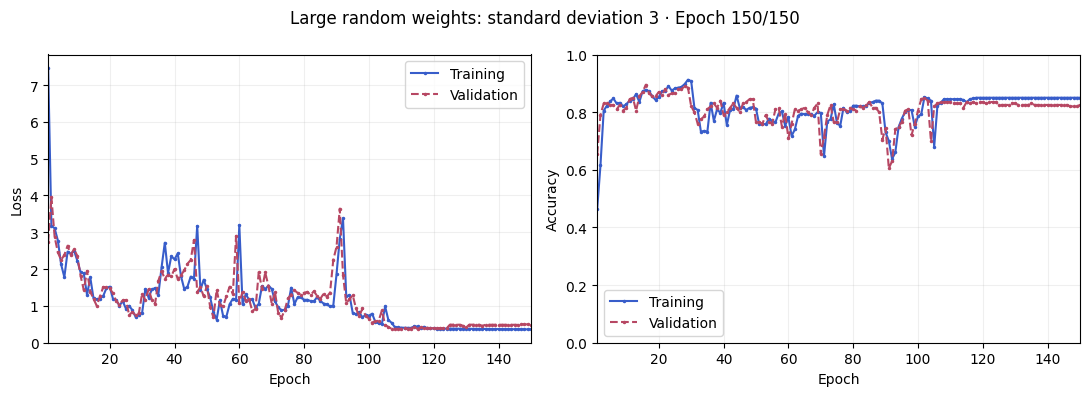

Hidden layer,Initially near ±1 (%),Initial gradient size
1,48.6,22.046181
4,85.6,0.918315
8,77.3,0.131103


In [ ]:
keras.utils.set_random_seed(42)

large_model = keras.Sequential([
    keras.Input(shape=(2,)),
    keras.layers.Dense(16, activation="tanh", kernel_initializer=keras.initializers.RandomNormal(stddev=3.0)),
    keras.layers.Dense(16, activation="tanh", kernel_initializer=keras.initializers.RandomNormal(stddev=3.0)),
    keras.layers.Dense(16, activation="tanh", kernel_initializer=keras.initializers.RandomNormal(stddev=3.0)),
    keras.layers.Dense(16, activation="tanh", kernel_initializer=keras.initializers.RandomNormal(stddev=3.0)),
    keras.layers.Dense(16, activation="tanh", kernel_initializer=keras.initializers.RandomNormal(stddev=3.0)),
    keras.layers.Dense(16, activation="tanh", kernel_initializer=keras.initializers.RandomNormal(stddev=3.0)),
    keras.layers.Dense(16, activation="tanh", kernel_initializer=keras.initializers.RandomNormal(stddev=3.0)),
    keras.layers.Dense(16, activation="tanh", kernel_initializer=keras.initializers.RandomNormal(stddev=3.0)),
    keras.layers.Dense(1, activation="sigmoid", kernel_initializer=keras.initializers.RandomNormal(stddev=3.0))
])

large_model.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.1),
    loss="binary_crossentropy", metrics=["accuracy"]
)
large_live = LivePlot("Large random weights: standard deviation 3", "large_tanh")
large_history = large_model.fit(
    X_train, y_train, validation_data=(X_val, y_val),
    epochs=150, batch_size=len(X_train), shuffle=False, verbose=0,
    callbacks=[large_live]
)

### Try replacing tanh with ReLU

tanh at least has a ceiling of 1. ReLU has no ceiling at all on the positive side, so large values can multiply up layer after layer.

**Watch:** the first weight and its gradient. Training stops if the loss becomes non-finite.

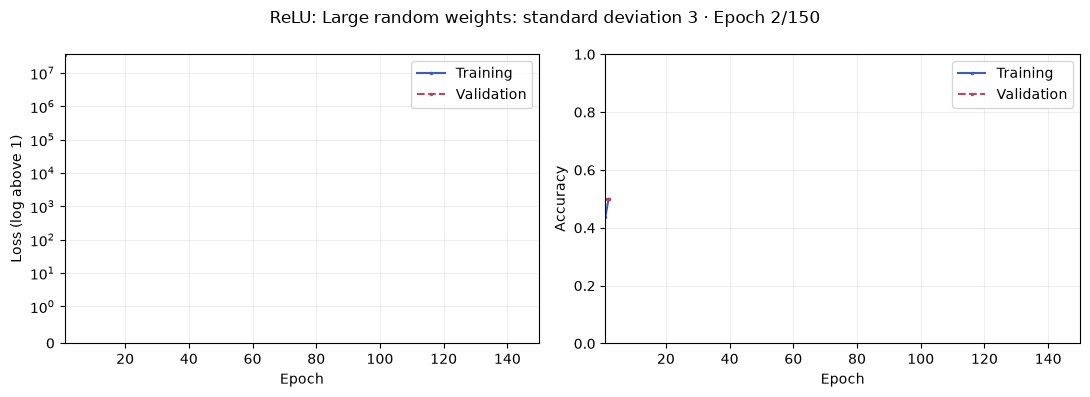

Epoch,Input 1 weight,Its gradient
0,-1.415351,"704,310.12"
1,"-70,432.43",Non-finite
2,Non-finite,Non-finite


Training stopped: the loss became non-finite.


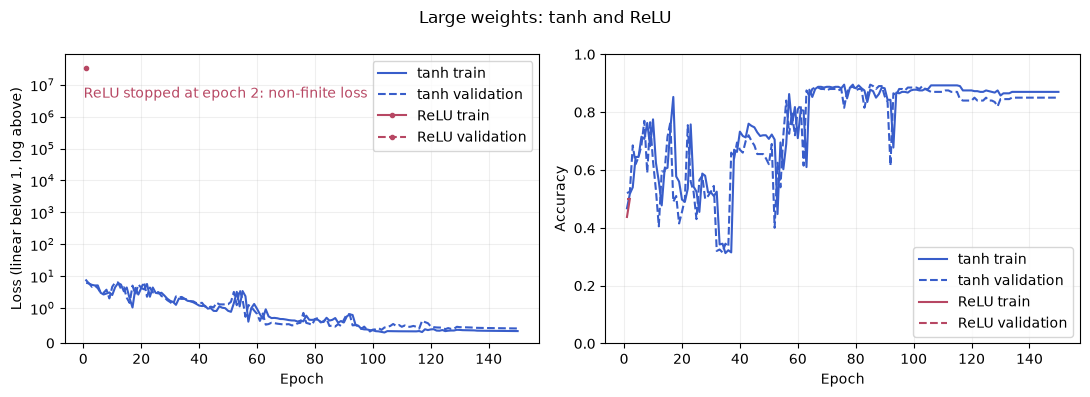

In [ ]:
keras.utils.set_random_seed(42)

large_relu_model = keras.Sequential([
    keras.Input(shape=(2,)),
    keras.layers.Dense(16, activation="relu", kernel_initializer=keras.initializers.RandomNormal(stddev=3.0)),
    keras.layers.Dense(16, activation="relu", kernel_initializer=keras.initializers.RandomNormal(stddev=3.0)),
    keras.layers.Dense(16, activation="relu", kernel_initializer=keras.initializers.RandomNormal(stddev=3.0)),
    keras.layers.Dense(16, activation="relu", kernel_initializer=keras.initializers.RandomNormal(stddev=3.0)),
    keras.layers.Dense(16, activation="relu", kernel_initializer=keras.initializers.RandomNormal(stddev=3.0)),
    keras.layers.Dense(16, activation="relu", kernel_initializer=keras.initializers.RandomNormal(stddev=3.0)),
    keras.layers.Dense(16, activation="relu", kernel_initializer=keras.initializers.RandomNormal(stddev=3.0)),
    keras.layers.Dense(16, activation="relu", kernel_initializer=keras.initializers.RandomNormal(stddev=3.0)),
    keras.layers.Dense(1, activation="sigmoid", kernel_initializer=keras.initializers.RandomNormal(stddev=3.0))
])

large_relu_model.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.1),
    loss="binary_crossentropy", metrics=["accuracy"]
)
large_relu_live = LivePlot("ReLU: Large random weights: standard deviation 3", "large_relu")
large_relu_history = large_relu_model.fit(
    X_train, y_train, validation_data=(X_val, y_val),
    epochs=150, batch_size=len(X_train), shuffle=False, verbose=0,
    callbacks=[keras.callbacks.TerminateOnNaN(), large_relu_live]
)
compare_runs(large_history, large_relu_history, "Large weights")

**Result:** tanh trains erratically. **85.6% of layer 4's outputs are already past $\pm0.99$** at the start, where the slope is 0.02, and the gradient sizes are wildly uneven across layers: **15.25** at layer 1 against **0.13** at layer 8.

ReLU is worse. The first gradient is **704,310**, the weight lands at **−70,432** after one step, and epoch 2 is non-finite. Training stops.

**The lesson:** **too large explodes.** Too small vanished. The usable scale sits between them, and guessing by hand is not a method.

**Next:** compute the scale instead of guessing.

## Where we are

| Start | What happened | What it was missing |
|---|---|---|
| Zero | Nothing moved at all | Neurons must differ |
| Same value everywhere | Neurons stayed identical | Neurons must differ |
| Random, 0.01 | Gradients vanished | The right scale |
| Random, 3 | Gradients exploded | The right scale |

Two failures are about **sameness**. Random fixed those.

Two failures are about **scale**, and random did nothing for them.

So: **where does the right scale come from?**

## 6. Xavier: let the layer widths choose the scale

Think about one neuron. It adds up $n_{\mathrm{in}}$ incoming signals:

$$z=w_1x_1+w_2x_2+\dots+w_{n_{\mathrm{in}}}x_{n_{\mathrm{in}}}$$

**More inputs means a bigger sum.** A layer with 784 inputs piles up 784 terms; a layer with 2 inputs piles up 2. If the weights are the same size in both, the wide layer produces far larger values.

So make the weights **smaller when the layer is wider**, chosen so a layer's output has roughly the same spread as its input. Do that at every layer and the signal neither shrinks nor grows as it travels.

Xavier (Glorot) balances the forward pass and the backward pass by using both widths:

$$s=\sqrt{\frac{2}{n_{\mathrm{in}}+n_{\mathrm{out}}}}$$

**Our network** (2 inputs, eight layers of 16, one output):

| Layer | $n_{\mathrm{in}}$ | $n_{\mathrm{out}}$ | $s$ |
|---|---|---|---|
| Input to hidden 1 | 2 | 16 | $\sqrt{2/18}=0.333$ |
| Hidden to hidden | 16 | 16 | $\sqrt{2/32}=0.250$ |
| Hidden 8 to output | 16 | 1 | $\sqrt{2/17}=0.343$ |

**A wider network**, the usual MNIST shape (784 inputs, 128 hidden, 10 outputs):

| Layer | $n_{\mathrm{in}}$ | $n_{\mathrm{out}}$ | $s$ |
|---|---|---|---|
| Input to hidden | 784 | 128 | $\sqrt{2/912}=0.047$ |
| Hidden to output | 128 | 10 | $\sqrt{2/138}=0.120$ |

Same rule, very different numbers: **0.250 for our hidden layers, 0.047 for the wide one.** Neither 0.01 nor 3 was ever going to suit both.

The cell below prints the formula next to the standard deviation Keras actually drew. Small weight matrices wobble around the target, that is just sampling.


In [ ]:
# The formula against what Keras actually samples
keras.utils.set_random_seed(42)

for n_in, n_out in [(2, 16), (16, 16), (16, 1), (784, 128), (128, 10)]:
    layer = keras.layers.Dense(n_out, kernel_initializer=keras.initializers.GlorotNormal())
    layer.build((None, n_in))
    print(f"{n_in:4d} to {n_out:4d}   formula {np.sqrt(2 / (n_in + n_out)):.3f}"
          f"   sampled {layer.kernel.numpy().std():.3f}")

Keras calls this `GlorotNormal`. Now train the same eight layers with it, using tanh.

**Watch:** training and validation loss.

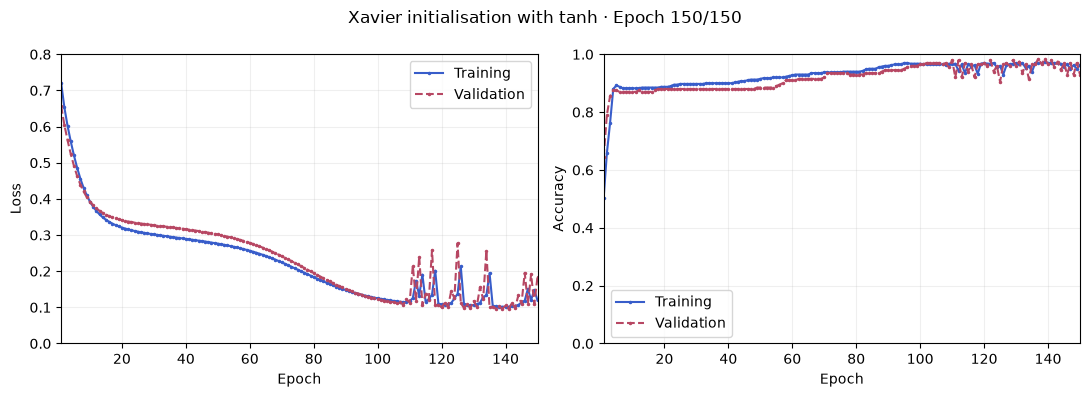

Epoch,Training loss,Validation loss
1,0.720684,0.656683
10,0.392583,0.392419
150,0.119263,0.184132


In [ ]:
keras.utils.set_random_seed(42)

xavier_model = keras.Sequential([
    keras.Input(shape=(2,)),
    keras.layers.Dense(16, activation="tanh", kernel_initializer=keras.initializers.GlorotNormal()),
    keras.layers.Dense(16, activation="tanh", kernel_initializer=keras.initializers.GlorotNormal()),
    keras.layers.Dense(16, activation="tanh", kernel_initializer=keras.initializers.GlorotNormal()),
    keras.layers.Dense(16, activation="tanh", kernel_initializer=keras.initializers.GlorotNormal()),
    keras.layers.Dense(16, activation="tanh", kernel_initializer=keras.initializers.GlorotNormal()),
    keras.layers.Dense(16, activation="tanh", kernel_initializer=keras.initializers.GlorotNormal()),
    keras.layers.Dense(16, activation="tanh", kernel_initializer=keras.initializers.GlorotNormal()),
    keras.layers.Dense(16, activation="tanh", kernel_initializer=keras.initializers.GlorotNormal()),
    keras.layers.Dense(1, activation="sigmoid", kernel_initializer=keras.initializers.GlorotNormal())
])

xavier_model.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.1),
    loss="binary_crossentropy", metrics=["accuracy"]
)
xavier_live = LivePlot("Xavier initialisation with tanh", "scale")
xavier_history = xavier_model.fit(
    X_train, y_train, validation_data=(X_val, y_val),
    epochs=150, batch_size=len(X_train), shuffle=False, verbose=0,
    callbacks=[xavier_live]
)

**Result:** it learns. Validation loss **0.657 at epoch 1**, **0.392 at epoch 10**, **0.184 at epoch 150**.

Nothing changed except the starting numbers. Same data, same architecture, same learning rate as the runs that went nowhere.

**Next:** keep the same scale and swap tanh for ReLU.

## 7. Does Xavier work with ReLU?

Xavier assumes the activation passes the signal through roughly unchanged. Near zero, tanh does: its slope there is 1.

**ReLU does not.** It keeps the positive half and sets the rest to zero.

Keep the same starting weights, change only the hidden activation, and compare the loss at **epoch 10**.

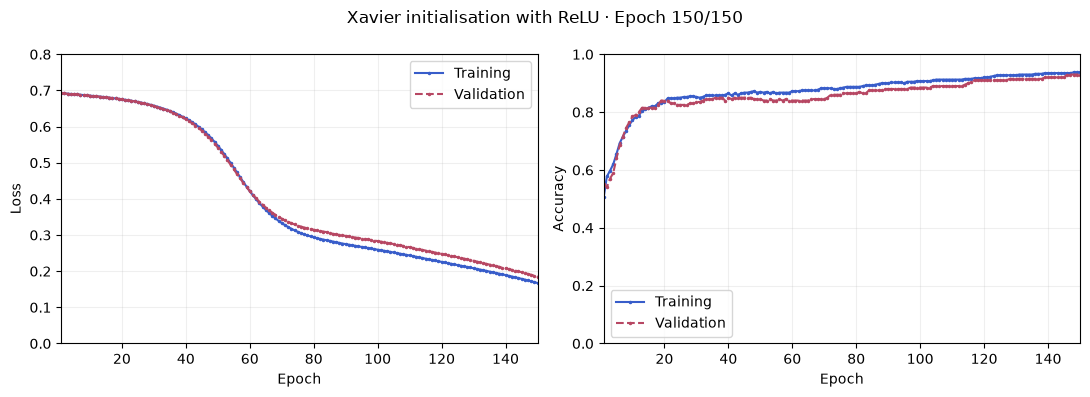

Epoch,Training loss,Validation loss
1,0.69233,0.69209
10,0.685607,0.685624
150,0.16739,0.18495


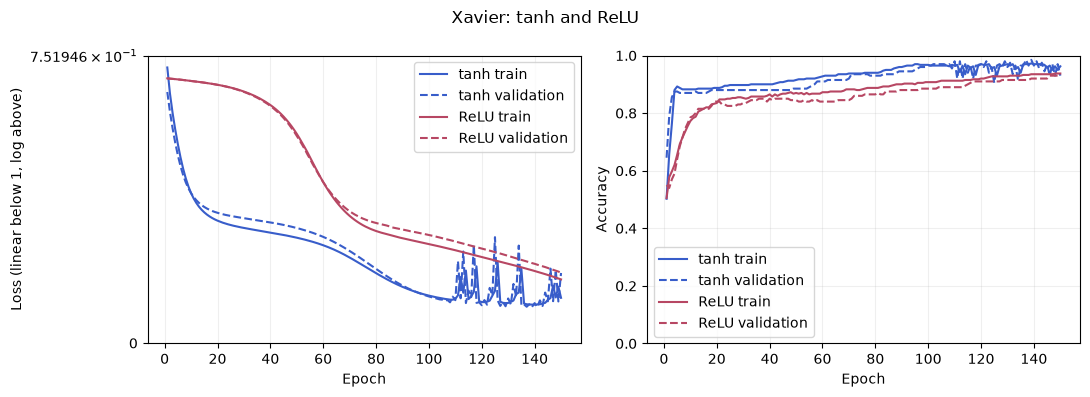

In [ ]:
keras.utils.set_random_seed(42)

relu_xavier_model = keras.Sequential([
    keras.Input(shape=(2,)),
    keras.layers.Dense(16, activation="relu", kernel_initializer=keras.initializers.GlorotNormal()),
    keras.layers.Dense(16, activation="relu", kernel_initializer=keras.initializers.GlorotNormal()),
    keras.layers.Dense(16, activation="relu", kernel_initializer=keras.initializers.GlorotNormal()),
    keras.layers.Dense(16, activation="relu", kernel_initializer=keras.initializers.GlorotNormal()),
    keras.layers.Dense(16, activation="relu", kernel_initializer=keras.initializers.GlorotNormal()),
    keras.layers.Dense(16, activation="relu", kernel_initializer=keras.initializers.GlorotNormal()),
    keras.layers.Dense(16, activation="relu", kernel_initializer=keras.initializers.GlorotNormal()),
    keras.layers.Dense(16, activation="relu", kernel_initializer=keras.initializers.GlorotNormal()),
    keras.layers.Dense(1, activation="sigmoid", kernel_initializer=keras.initializers.GlorotNormal())
])

relu_xavier_model.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.1),
    loss="binary_crossentropy", metrics=["accuracy"]
)
relu_xavier_live = LivePlot("Xavier initialisation with ReLU", "scale")
relu_xavier_history = relu_xavier_model.fit(
    X_train, y_train, validation_data=(X_val, y_val),
    epochs=150, batch_size=len(X_train), shuffle=False, verbose=0,
    callbacks=[relu_xavier_live]
)
compare_runs(xavier_history, relu_xavier_history, "Xavier")

**Result:** it does learn, but the start is much slower. Validation loss at epoch 10 is **0.686**, against **0.392** for tanh. The first ten epochs are nearly flat.

Why: roughly half the values arriving at a ReLU layer are negative, and ReLU sets those to zero. Each layer therefore passes on about **half** the squared signal. Over eight layers that is $(1/2)^8=1/256$.

Xavier's scale is right for an activation that keeps both halves. **ReLU throws one half away.**

**Next:** put the missing half back.

## 8. He: put the factor of 2 back for ReLU

ReLU halves the average squared signal at every layer, so the repair is direct: **start with twice the variance**, which means $\sqrt{2}$ times the weights.

He also drops $n_{\mathrm{out}}$ and scales on the incoming width alone:

$$s=\sqrt{\frac{2}{n_{\mathrm{in}}}}$$

| Layer | $n_{\mathrm{in}}$ | Xavier $s$ | He $s$ |
|---|---|---|---|
| Input to hidden 1 | 2 | 0.333 | $\sqrt{2/2}=1.000$ |
| Hidden to hidden | 16 | 0.250 | $\sqrt{2/16}=0.354$ |
| 784 to 128 (wide net) | 784 | 0.047 | $\sqrt{2/784}=0.051$ |

For a square layer the two differ by exactly $\sqrt2$: $0.250\times1.414=0.354$. That $\sqrt2$ **is** the half ReLU removes.

**Watch:** compare epoch 10 with the previous run.

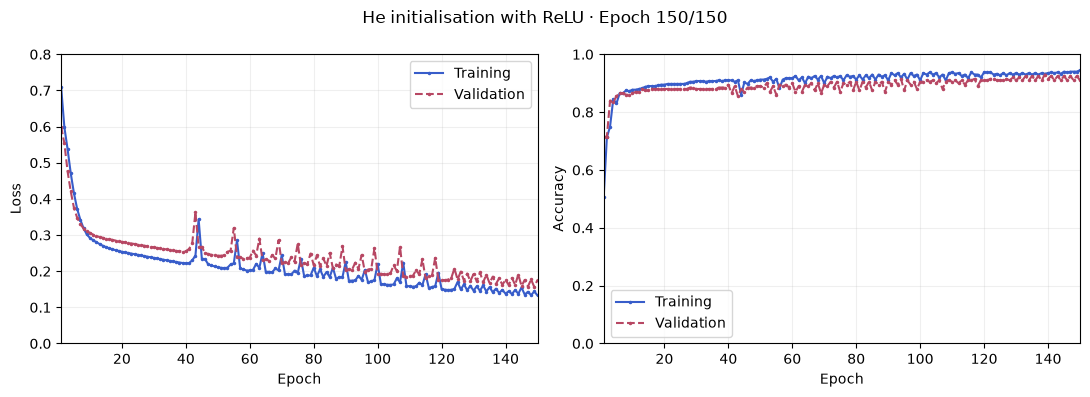

Epoch,Training loss,Validation loss
1,0.708476,0.59987
10,0.292034,0.306101
150,0.132768,0.176026


In [ ]:
keras.utils.set_random_seed(42)

he_model = keras.Sequential([
    keras.Input(shape=(2,)),
    keras.layers.Dense(16, activation="relu", kernel_initializer=keras.initializers.HeNormal()),
    keras.layers.Dense(16, activation="relu", kernel_initializer=keras.initializers.HeNormal()),
    keras.layers.Dense(16, activation="relu", kernel_initializer=keras.initializers.HeNormal()),
    keras.layers.Dense(16, activation="relu", kernel_initializer=keras.initializers.HeNormal()),
    keras.layers.Dense(16, activation="relu", kernel_initializer=keras.initializers.HeNormal()),
    keras.layers.Dense(16, activation="relu", kernel_initializer=keras.initializers.HeNormal()),
    keras.layers.Dense(16, activation="relu", kernel_initializer=keras.initializers.HeNormal()),
    keras.layers.Dense(16, activation="relu", kernel_initializer=keras.initializers.HeNormal()),
    keras.layers.Dense(1, activation="sigmoid", kernel_initializer=keras.initializers.HeNormal())
])

he_model.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.1),
    loss="binary_crossentropy", metrics=["accuracy"]
)
he_live = LivePlot("He initialisation with ReLU", "scale")
he_history = he_model.fit(
    X_train, y_train, validation_data=(X_val, y_val),
    epochs=150, batch_size=len(X_train), shuffle=False, verbose=0,
    callbacks=[he_live]
)

**Result:** validation loss at epoch 10 is **0.306**, against **0.686** with Xavier. Same activation, same network, same data. Only the starting scale differs, by a factor of $\sqrt2$ per layer.

By epoch 150 both sit near 0.18. **The scale mostly buys you the early epochs**, and on a deeper network it buys you whether training starts at all.

## Keep these ideas

| Start | Lesson |
|---|---|
| Zero | A single neuron can learn. This all-zero hidden network cannot. |
| Equal | Repeated neurons add no distinct features. |
| Random | Different weights still need a useful scale. |
| Xavier / He | Match the starting scale to the layer widths and activation. |

**The whole session in one line:** start **different**, and start at the **right scale**.

**The decision in practice:**

| Hidden activation | Use | Keras |
|---|---|---|
| tanh, sigmoid | Xavier / Glorot | `GlorotNormal()`, `GlorotUniform()` |
| ReLU and its relatives | He | `HeNormal()`, `HeUniform()` |

Keras already defaults to `glorot_uniform`, which is why a careless network usually still trains. On a deep ReLU stack, ask for `HeNormal()`.

These observations describe this fixed run. Devices and library versions can change the curves.

Reference: [Keras initialisers](https://keras.io/api/layers/initializers/).

In [ ]:
# Fill the Feedback